# 🚀 Master Thesis: The Ultimate Container Vulnerability Scanner Evaluation
This notebook serves as the definitive analysis of scanner performance across different Quarkus container builds.


In [1]:
import os, json, re, warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from upsetplot import UpSet, from_memberships

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="deep")


In [2]:
# Parsing Logic
def parse_trivy(filepath, img_name, scan_type):
    if not os.path.exists(filepath): return pd.DataFrame()
    with open(filepath, 'r') as f:
        try: data = json.load(f)
        except: return pd.DataFrame()
    rows = []
    for result in data.get('Results', []):
        vuln_class = result.get('Class', 'unknown')
        for v in result.get('Vulnerabilities', []):
            cvss_score = None
            if v.get('CVSS'):
                for vendor, scores in v['CVSS'].items():
                    if 'V3Score' in scores:
                        cvss_score = scores['V3Score']
                        break
            rows.append({
                'image': img_name, 'scan_type': scan_type, 'cve_id': v.get('VulnerabilityID', ''),
                'scanner': 'Trivy', 'package_name': v.get('PkgName', ''),
                'severity': (v.get('Severity', 'UNKNOWN') or 'UNKNOWN').upper(),
                'cvss_score': cvss_score, 'vuln_class': vuln_class
            })
    return pd.DataFrame(rows)

def parse_grype(filepath, img_name, scan_type):
    if not os.path.exists(filepath): return pd.DataFrame()
    with open(filepath, 'r') as f:
        try: data = json.load(f)
        except: return pd.DataFrame()
    rows = []
    for match in data.get('matches', []):
        vuln = match.get('vulnerability', {})
        artifact = match.get('artifact', {})
        cve_id = vuln.get('id', '')
        if not cve_id.startswith('CVE-'):
            for rv in match.get('relatedVulnerabilities', []):
                if rv.get('id', '').startswith('CVE-'):
                    cve_id = rv['id']
                    break
        cvss_score = None
        for c in vuln.get('cvss', []):
            if c.get('metrics', {}).get('baseScore'):
                cvss_score = c['metrics']['baseScore']
                break
        severity = (vuln.get('severity', 'UNKNOWN') or 'UNKNOWN').upper().replace('NEGLIGIBLE', 'LOW')
        vuln_class = artifact.get('type', 'unknown')
        rows.append({
            'image': img_name, 'scan_type': scan_type, 'cve_id': cve_id,
            'scanner': 'Grype', 'package_name': artifact.get('name', ''),
            'severity': severity, 'cvss_score': cvss_score, 'vuln_class': vuln_class
        })
    return pd.DataFrame(rows)

def parse_snyk(filepath, img_name, scan_type):
    if not os.path.exists(filepath): return pd.DataFrame()
    with open(filepath, 'r') as f:
        try: data = json.load(f)
        except: return pd.DataFrame()
    rows = []
    for v in data.get('vulnerabilities', []):
        cve_ids = v.get('identifiers', {}).get('CVE', [])
        cve_id = cve_ids[0] if cve_ids else v.get('id', '')
        severity_raw = (v.get('severity', 'unknown') or 'unknown').upper()
        if severity_raw in ('MEDIUM', 'MODERATE'): severity = 'MEDIUM'
        else: severity = severity_raw
        
        vuln_class = v.get('language', 'unknown')
        if vuln_class == 'linux': vuln_class = 'os-pkgs'
        elif vuln_class == 'java': vuln_class = 'lang-pkgs'
        
        rows.append({
            'image': img_name, 'scan_type': scan_type, 'cve_id': cve_id,
            'scanner': 'Snyk', 'package_name': v.get('packageName', ''),
            'severity': severity, 'cvss_score': v.get('cvssScore'), 'vuln_class': vuln_class
        })
    return pd.DataFrame(rows)

def parse_scout(filepath, img_name, scan_type):
    if not os.path.exists(filepath): return pd.DataFrame()
    with open(filepath, 'r') as f:
        try: data = json.load(f)
        except: return pd.DataFrame()
    if not data.get("runs"): return pd.DataFrame()
    rows = []
    run = data['runs'][0]
    rules = {r['id']: r for r in run['tool']['driver'].get('rules', [])}
    for result in run.get('results', []):
        rule_id = result.get('ruleId', '')
        rule = rules.get(rule_id, {})
        props = rule.get('properties', {})
        pkg_name = ''
        purls = props.get('purls', [])
        if purls:
            match = re.match(r'pkg:[^/]+/(?:[^/]+/)?([^@]+)@([^?]+)', purls[0])
            if match: pkg_name = match.group(1)
        severity = (props.get('cvssV3_severity', 'UNKNOWN') or 'UNKNOWN').upper()
        if severity == 'MODERATE': severity = 'MEDIUM'
        rows.append({
            'image': img_name, 'scan_type': scan_type, 'cve_id': rule_id,
            'scanner': 'Docker Scout', 'package_name': pkg_name,
            'severity': severity, 'cvss_score': props.get('cvssV3'), 'vuln_class': 'os-pkgs'
        })
    return pd.DataFrame(rows)


## Load and Deduplicate Data


In [3]:
results_dir = "results"
all_data = []
images = [d for d in os.listdir(results_dir) if os.path.isdir(os.path.join(results_dir, d))]

for img in images:
    img_dir = os.path.join(results_dir, img)
    img_name = img.replace("qscan.io_vulnerable-quarkus_", "")
    
    all_data.append(parse_trivy(f"{img_dir}/trivy.json", img_name, "Direct"))
    all_data.append(parse_grype(f"{img_dir}/grype.json", img_name, "Direct"))
    all_data.append(parse_snyk(f"{img_dir}/snyk.json", img_name, "Direct"))
    all_data.append(parse_scout(f"{img_dir}/docker-scout.sarif.json", img_name, "Direct"))

    for gen in ["syft", "trivy", "scout"]:
        sbom_dir = f"{img_dir}/sbom/{gen}"
        if not os.path.exists(sbom_dir): continue
        all_data.append(parse_trivy(f"{sbom_dir}/trivy.json", img_name, f"SBOM ({gen})"))
        all_data.append(parse_grype(f"{sbom_dir}/grype.json", img_name, f"SBOM ({gen})"))
        all_data.append(parse_snyk(f"{sbom_dir}/snyk.json", img_name, f"SBOM ({gen})"))
        all_data.append(parse_scout(f"{sbom_dir}/docker-scout.sarif.json", img_name, f"SBOM ({gen})"))

df_all = pd.concat(all_data, ignore_index=True)
df_all = df_all[df_all['cve_id'].str.startswith('CVE-')].copy()
df_dedup = df_all.drop_duplicates(subset=['image', 'scan_type', 'cve_id', 'scanner', 'package_name']).copy()

def normalize_vuln_type(row):
    cls = str(row['vuln_class']).lower()
    if cls in ['os-pkgs', 'rpm', 'deb', 'apk', 'linux']: return 'OS'
    elif cls in ['lang-pkgs', 'java-archive', 'java', 'maven']: return 'Application'
    else: return 'Unknown'

df_dedup['vuln_category'] = df_dedup.apply(normalize_vuln_type, axis=1)
direct_df = df_dedup[df_dedup["scan_type"] == "Direct"].copy()
print(f"Total Unique Vuln Entries Parsed: {len(df_dedup)}")


Total Unique Vuln Entries Parsed: 10546


## 1. High-Level Scanner Comparison (Direct Scans)


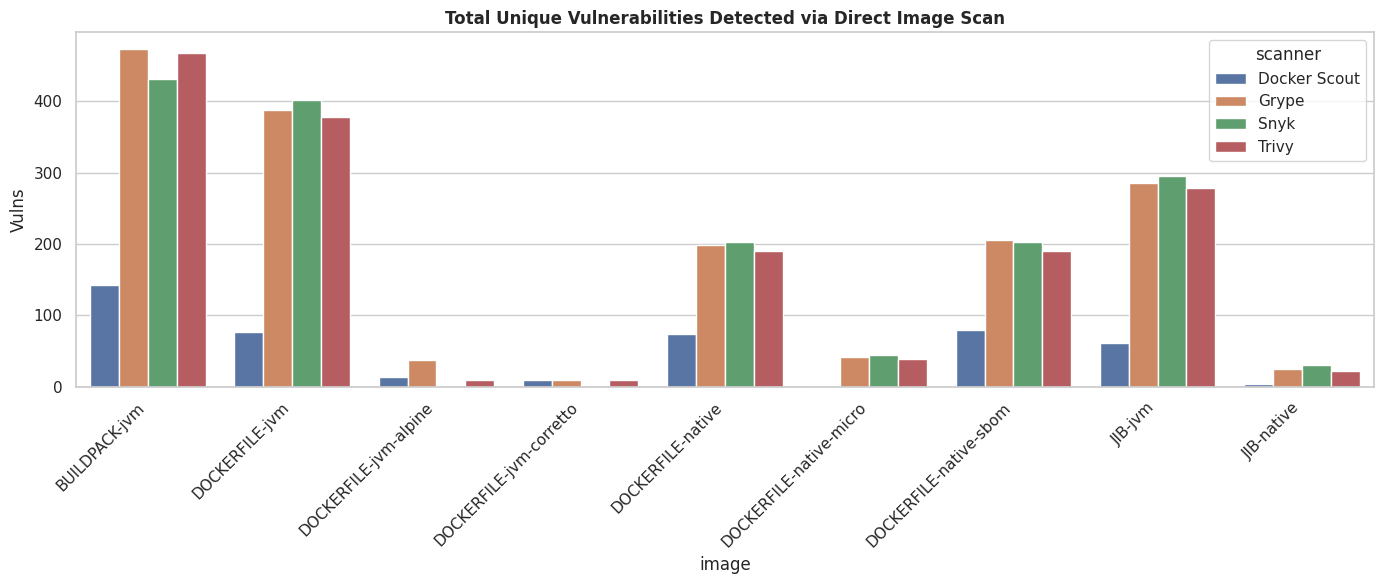

In [4]:
counts_df = direct_df.groupby(['image', 'scanner']).size().reset_index(name='Vulns')
plt.figure(figsize=(14, 6))
sns.barplot(data=counts_df, x="image", y="Vulns", hue="scanner")
plt.xticks(rotation=45, ha='right')
plt.title("Total Unique Vulnerabilities Detected via Direct Image Scan", fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Severity and CVSS Score Distributions


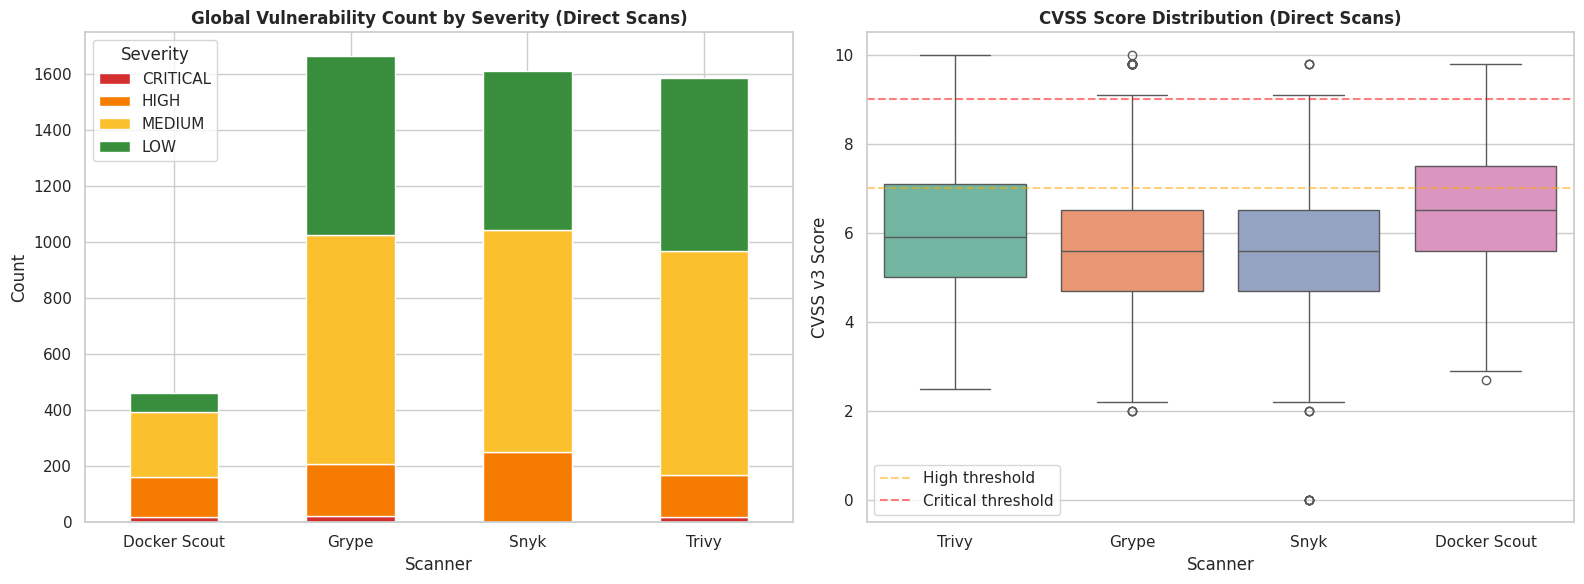

In [5]:
severity_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'UNKNOWN']
sev_pivot = direct_df.groupby(['scanner', 'severity']).size().unstack(fill_value=0)
sev_pivot = sev_pivot.reindex(columns=[s for s in severity_order if s in sev_pivot.columns])
colors = {'CRITICAL': '#d32f2f', 'HIGH': '#f57c00', 'MEDIUM': '#fbc02d', 'LOW': '#388e3c', 'UNKNOWN': '#9e9e9e'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sev_pivot.plot(kind='bar', stacked=True, ax=axes[0], color=[colors.get(c, '#9e9e9e') for c in sev_pivot.columns])
axes[0].set_title('Global Vulnerability Count by Severity (Direct Scans)', fontweight='bold')
axes[0].set_xlabel('Scanner')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Severity')

df_cvss = direct_df.dropna(subset=['cvss_score'])
if not df_cvss.empty:
    sns.boxplot(data=df_cvss, x='scanner', y='cvss_score', ax=axes[1], palette='Set2')
    axes[1].set_title('CVSS Score Distribution (Direct Scans)', fontweight='bold')
    axes[1].set_xlabel('Scanner')
    axes[1].set_ylabel('CVSS v3 Score')
    axes[1].axhline(y=7.0, color='orange', linestyle='--', alpha=0.5, label='High threshold')
    axes[1].axhline(y=9.0, color='red', linestyle='--', alpha=0.5, label='Critical threshold')
    axes[1].legend()

plt.tight_layout()
plt.show()


## 3. The Great CVE Overlap (Upset Plot)


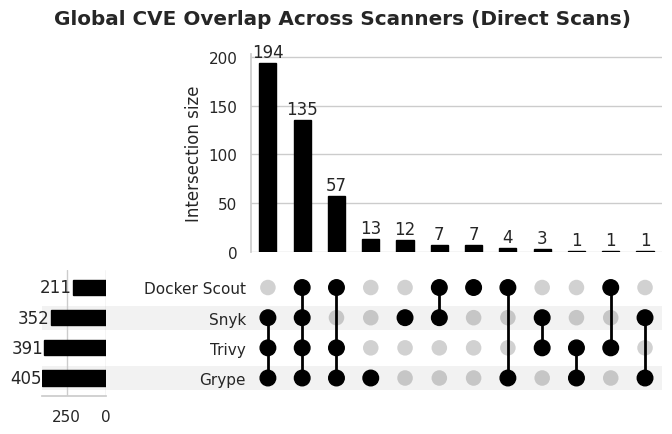

In [6]:
cve_sets = {}
scanners = ['Trivy', 'Grype', 'Snyk', 'Docker Scout']
for scanner in scanners:
    cve_sets[scanner] = set(direct_df[direct_df['scanner'] == scanner]['cve_id'].unique())

all_cves = set.union(*[s for s in cve_sets.values() if s])
memberships = []
for cve in all_cves:
    memberships.append([s for s in scanners if cve in cve_sets[s]])

upset_data = from_memberships(memberships)
upset = UpSet(upset_data, subset_size='count', show_counts=True, sort_by='cardinality')
upset.plot()
plt.suptitle('Global CVE Overlap Across Scanners (Direct Scans)', fontweight='bold')
plt.show()


## 4. OS vs Application Vulnerabilities


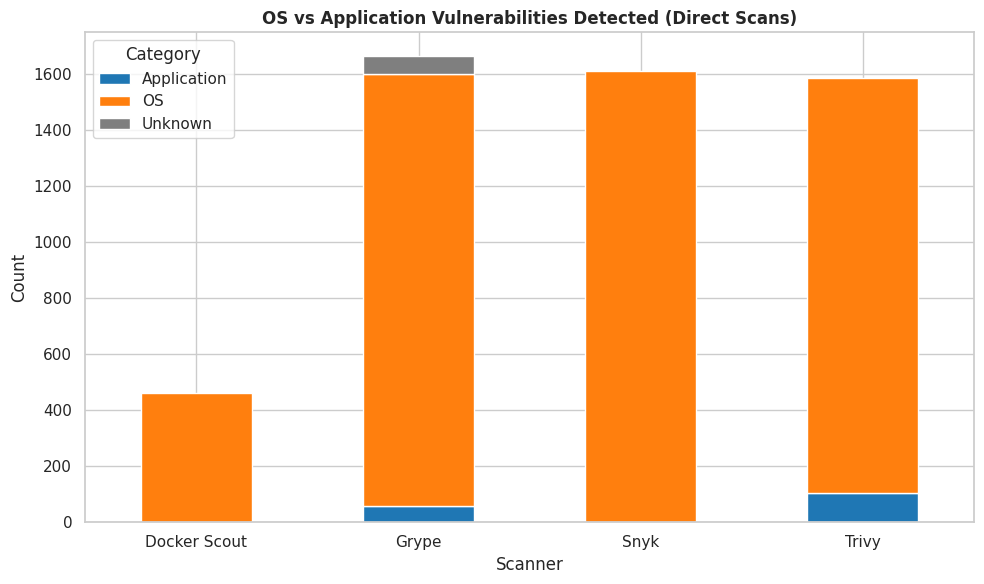

In [7]:
cat_df = direct_df.groupby(['scanner', 'vuln_category']).size().unstack(fill_value=0)
cat_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e', '#7f7f7f'])
plt.title('OS vs Application Vulnerabilities Detected (Direct Scans)', fontweight='bold')
plt.xlabel('Scanner')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Category')
plt.tight_layout()
plt.show()


## 5. Impact of Build Methods and Base Images


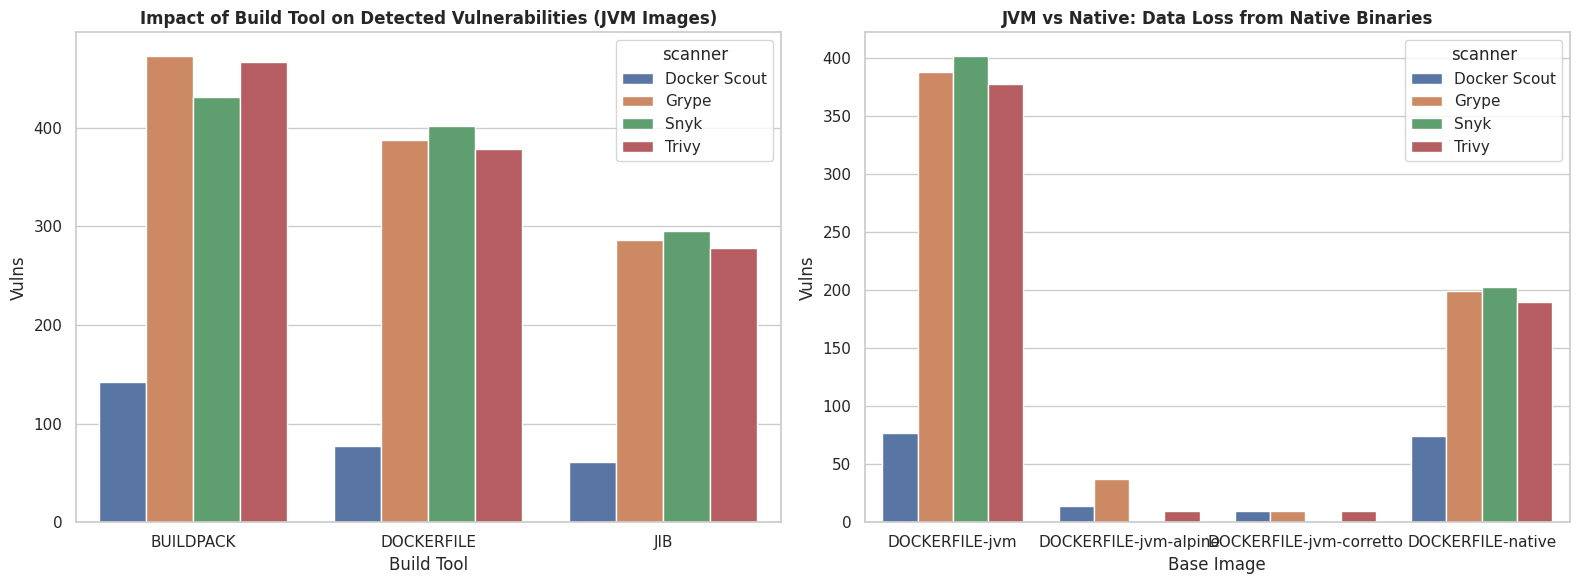

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# JIB vs DOCKERFILE vs BUILDPACK (JVM)
jvm_df = direct_df[direct_df['image'].str.endswith('-jvm')].copy()
jvm_df['build_tool'] = jvm_df['image'].apply(lambda x: x.split('-')[0])
tool_counts = jvm_df.groupby(['build_tool', 'scanner']).size().reset_index(name='Vulns')
sns.barplot(data=tool_counts, x='build_tool', y='Vulns', hue='scanner', ax=axes[0])
axes[0].set_title('Impact of Build Tool on Detected Vulnerabilities (JVM Images)', fontweight='bold')
axes[0].set_xlabel('Build Tool')

# Native vs JVM (Data Loss)
native_jvm_df = counts_df[counts_df["image"].str.contains("DOCKERFILE-jvm|DOCKERFILE-native$")]
sns.barplot(data=native_jvm_df, x="image", y="Vulns", hue="scanner", ax=axes[1])
axes[1].set_title("JVM vs Native: Data Loss from Native Binaries", fontweight='bold')
axes[1].set_xlabel('Base Image')

plt.tight_layout()
plt.show()


## 6. Direct vs SBOM Scanning Discrepancies


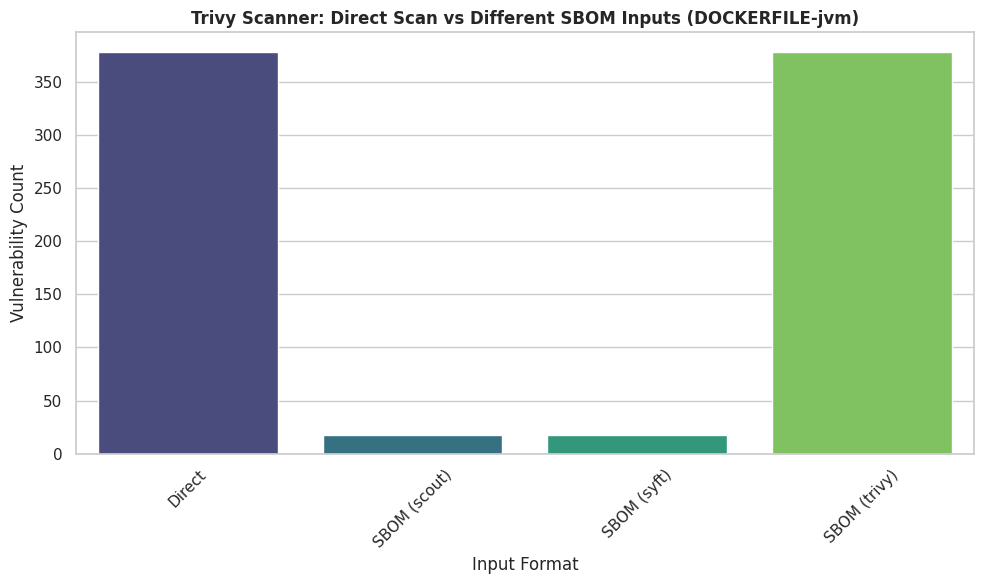

In [9]:
trivy_sbom_df = df_dedup[(df_dedup['scanner'] == 'Trivy') & (df_dedup['image'] == 'DOCKERFILE-jvm')]
trivy_counts = trivy_sbom_df.groupby(['scan_type']).size().reset_index(name='Vulns')

plt.figure(figsize=(10, 6))
sns.barplot(data=trivy_counts, x='scan_type', y='Vulns', palette="viridis")
plt.title('Trivy Scanner: Direct Scan vs Different SBOM Inputs (DOCKERFILE-jvm)', fontweight='bold')
plt.xlabel('Input Format')
plt.ylabel('Vulnerability Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
